# Exploratory Data Analysis (EDA) on Titanic Dataset

This notebook performs dataset profiling, cleaning, exploratory data analysis, and exploratory standardization on the Titanic dataset. The cleaned dataset generated here is saved as `titanic.csv` and serves as the input for the predictive modeling notebook.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Dataset Loading and Profiling

Load the Titanic dataset and save it as an offline fallback using `df.to_save('titanic.csv, index=False)`. Print the dataset shape, information, summary statistics, and compute the percentage of missing values for every affected column.


In [2]:
df = sns.load_dataset('titanic')
display(df.head())


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.to_csv('titanic.csv', index=False)


### df.shape


In [4]:
print("="*20)
print("Shape of the dataset")
print("="*20)

print(f"Shape of the dataset: {df.shape}")
print(f"Number of records: {df.shape[0]} ")
print(f"Number of columns: {df.shape[1]} ")


Shape of the dataset
Shape of the dataset: (891, 15)
Number of records: 891 
Number of columns: 15 


### df.info()


In [5]:
print("="*20)
print("df.info()")
print("="*20)

print("Dataset Information:")
print(df.info())


df.info()
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None


### df.describe()


In [6]:
print("="*20)
print("df.describe()")
print("="*20)

print("Statistical Summary:")
display(df.describe())


df.describe()
Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Missing Values


In [7]:
print("="*20)
print("Missing Values")
print("="*20)

print("Number of Missing Values per Column:\nCOLUMN\t\tMISSING_VALUES")

for col, missing in df.isnull().sum().items():
    if missing > 0:
        print(f"{col}\t\t{missing}")

print("\nPercentage of Missing Values per Column:\nCOLUMN\t\tMISSING_PERCENTAGE")

missing_percentage = (df.isnull().mean() * 100).round(2)
missing_percentage = missing_percentage[missing_percentage > 0.00]

for col, pct in missing_percentage.items():
    print(f"{col}\t\t{pct}")


Missing Values
Number of Missing Values per Column:
COLUMN		MISSING_VALUES
age		177
embarked		2
deck		688
embark_town		2

Percentage of Missing Values per Column:
COLUMN		MISSING_PERCENTAGE
age		19.87
embarked		0.22
deck		77.22
embark_town		0.22


## Missing Value Handling and Data Cleaning

Using the missing-value percentages identified during profiling, each affected column is cleaned according to the predefined threshold strategy.

Under 5% missing -> drop those rows; 5%–30% missing -> impute; for any column whose missing rate is to high then drop column or encode as it own category.


In [8]:
print("\nCleaning Strategy")

for column, percentage in missing_percentage.items():
    if percentage < 5:
        print(f"- {column}: {percentage:.2f}% → Drop affected rows")
    elif 5 <= percentage <= 30:
        print(f"- {column}: {percentage:.2f}% → Impute missing values")
    else:
        print(f"- {column}: {percentage:.2f}% → Drop column")



Cleaning Strategy
- age: 19.87% → Impute missing values
- embarked: 0.22% → Drop affected rows
- deck: 77.22% → Drop column
- embark_town: 0.22% → Drop affected rows


### Missing Value Handling Strategy

- **embarked (≈0.22%)**: Since the missing rate is below 5%, the affected rows were removed. This results in minimal information loss while preserving data quality.
- **embark_town (≈0.22%)**: This column follows the same rule as embarked, as the missing values occur in the same records. The affected rows were removed.
- **age (≈19.87%)**: With a missing rate between 5% and 30%, median imputation was applied. The median is more robust than the mean because the age distribution contains potential outliers.
- **deck (≈77.22%)**: More than three-quarters of the observations are missing. Imputing such a large proportion would be unreliable and could introduce significant bias. Therefore, the column was removed from the analysis.


In [9]:
df.drop(columns=['deck'], inplace=True)


In [10]:
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)


In [11]:
df.dropna(subset=['embarked', 'embark_town'], inplace=True)


## Univariate Analysis

Investigate the distribution of individual numerical variables independently. Histograms and box plots are used to visualize the distributions of **age** and **fare**, while the Interquartile Range (IQR) rule is applied to identify and quantify potential outliers. In addition, the mean, median, and mode of the **fare** variable are computed to determine the direction of skewness by comparing the relative ordering of these three measures of central tendency.


In [12]:
def univariate_analysis(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.histplot(
        data=df,
        x=column,
        ax=axes[0],
        bins=30,
        color="steelblue"
    )
    axes[0].set_title(f'{column.capitalize()} Distribution')

    sns.boxplot(
        x=df[column],
        ax=axes[1],
        color="lightgreen"
    )
    axes[1].set_title(f'{column.capitalize()} Box Plot')

    plt.tight_layout()
    plt.show()

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print("="*23)
    print(f"{column.capitalize()} Univariate Analysis")
    print("="*23)
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {outliers.shape[0]}")

    return outliers


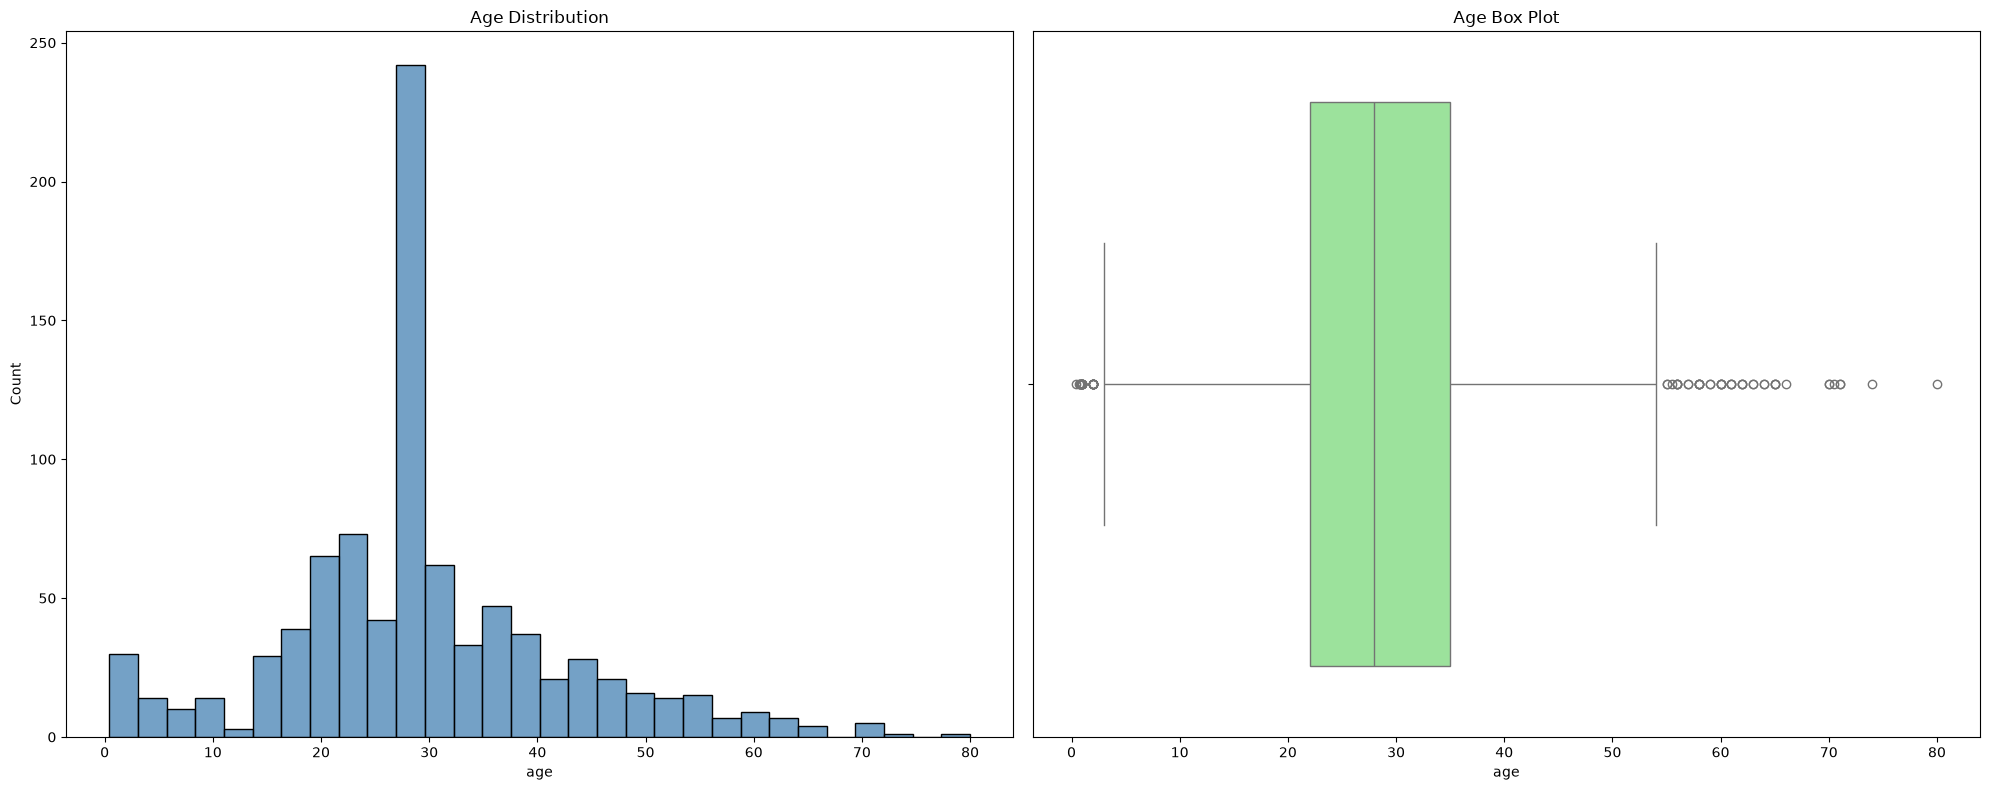

Age Univariate Analysis
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Number of Outliers: 65


In [13]:
age_outliers = univariate_analysis(df, 'age')


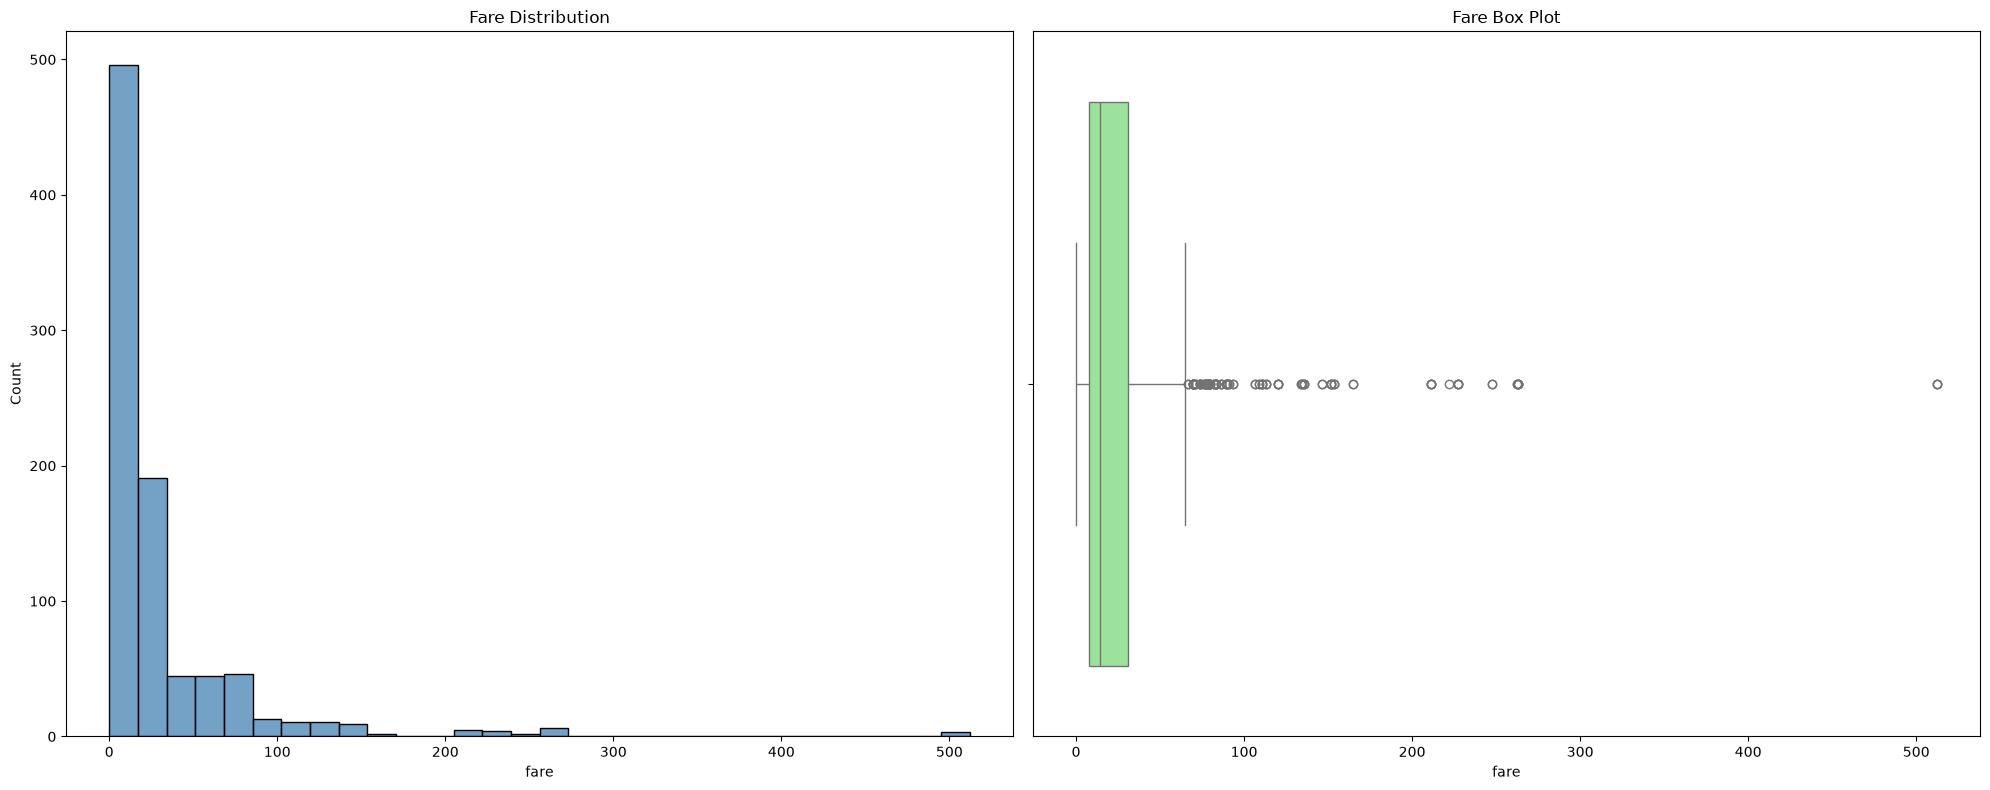

Fare Univariate Analysis
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower Bound: -26.7605
Upper Bound: 65.6563
Number of Outliers: 114


In [14]:
fare_outliers = univariate_analysis(df, 'fare')


### Fare Statistics


In [15]:
print("="*20)
print("Fare Statistics")
print("="*20)

fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]

print(f"Mean: {fare_mean}")
print(f"Median: {fare_median}")
print(f"Mode: {fare_mode}")

if fare_mean > fare_median > fare_mode:
    skew = "Right-Skewed "
elif fare_mean < fare_median < fare_mode:
    skew = "Left-Skewed "
else:
    skew = "Symmetric "

print(f"Skewness: {skew}")

print(f"\nMean: {fare_mean:.2f}, Median: {fare_median:.2f}, Mode: {fare_mode:.2f}")
print(f"The mean {fare_mean:.2f} is greater than the median {fare_median:.2f} and mode {fare_mode:.2f}, indicating a right-skewed distribution.")
print(
    "A small number of passengers paid exceptionally high fares, creating a long right tail that pulls the mean upward while most passengers paid relatively low fares."
)


Fare Statistics
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05
Skewness: Right-Skewed 

Mean: 32.10, Median: 14.45, Mode: 8.05
The mean 32.10 is greater than the median 14.45 and mode 8.05, indicating a right-skewed distribution.
A small number of passengers paid exceptionally high fares, creating a long right tail that pulls the mean upward while most passengers paid relatively low fares.


## Bivariate Analysis

The relationships between passenger survival and selected explanatory variables. Survival rates are computed using boolean masking for different passenger groups based on **sex**, **passenger class (pclass)**, and the combination of **sex and passenger class**. A correlation analysis is then performed using only the six specified numerical variables (`survived`, `pclass`, `age`, `sibsp`, `parch`, and `fare`) to quantify the strength of linear relationships. The two strongest feature relationships are identified from the correlation matrix and interpreted to understand their influence within the dataset.


### Survival Rate By Sex


In [16]:
print("="*20)
print("Survival Rate By Sex")
print("="*20)

male = df['sex'] == "male"
female = df['sex'] == "female"

male_sur_rate = df[male]['survived'].mean() * 100
female_sur_rate = df[female]['survived'].mean() * 100

print(f"Male Survival Rate: {male_sur_rate:.4f}")
print(f"Female Survival Rate: {female_sur_rate:.4f}")


Survival Rate By Sex
Male Survival Rate: 18.8908
Female Survival Rate: 74.0385


### Survival Rate By PClass


In [17]:
print("="*23)
print("Survival Rate By PClass")
print("="*23)

for pclass in df['pclass'].unique():
    sur_rate = df[df['pclass'] == pclass]['survived'].mean() * 100
    print(f"PClass {pclass} Survival Rate: {sur_rate:.4f}")


Survival Rate By PClass
PClass 3 Survival Rate: 24.2363
PClass 1 Survival Rate: 62.6168
PClass 2 Survival Rate: 47.2826


### Survival Rate by Sex and PClass


In [18]:
print("="*31)
print("Survival Rate by Sex and PClass")
print("="*31)

for sex in sorted(df['sex'].unique()):
    for pclass in sorted(df['pclass'].unique()):
        mask = (df['sex']==sex) & (df['pclass']==pclass)
        sur_rate = df[mask]['survived'].mean() * 100
        print(f"Sex: {sex}, PClass: {pclass} - Survival Rate: {sur_rate:.4f}%")


Survival Rate by Sex and PClass
Sex: female, PClass: 1 - Survival Rate: 96.7391%
Sex: female, PClass: 2 - Survival Rate: 92.1053%
Sex: female, PClass: 3 - Survival Rate: 50.0000%
Sex: male, PClass: 1 - Survival Rate: 36.8852%
Sex: male, PClass: 2 - Survival Rate: 15.7407%
Sex: male, PClass: 3 - Survival Rate: 13.5447%


### Correlation Matrix

correlation matrix is computed using only the six numerical variables (`survived`, `pclass`, `age`, `sibsp`, `parch`, and `fare`)


In [19]:
print("="*20)
print("Correlation Matrix")
print("="*20)

corr_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = (df[corr_cols].corr()).round(4)

display(corr_matrix)


Correlation Matrix


,survived,pclass,age,sibsp,parch,fare
survived,1.0000,-0.3355,-0.0698,-0.0340,0.0832,0.2553
pclass,-0.3355,1.0000,-0.3365,0.0817,0.0168,-0.5482
age,-0.0698,-0.3365,1.0000,-0.2325,-0.1715,0.0937
sibsp,-0.0340,0.0817,-0.2325,1.0000,0.4145,0.1609
parch,0.0832,0.0168,-0.1715,0.4145,1.0000,0.2175
fare,0.2553,-0.5482,0.0937,0.1609,0.2175,1.0000


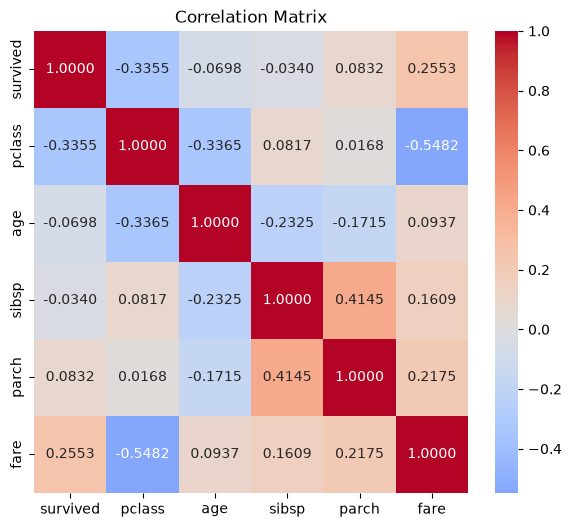

In [20]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".4f",
    center=0
)
plt.title("Correlation Matrix")
plt.show()


### Two Strongest Correlations


In [21]:
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c1, c2 = corr_cols[i], corr_cols[j]
        val = corr_matrix.loc[c1, c2]
        pairs.append((c1, c2, val, abs(val)))
 
pairs_sorted = sorted(pairs, key=lambda x: x[3], reverse=True)

print("\nAll off-diagonal pairs ranked by |correlation|:")
for c1, c2, val, absval in pairs_sorted:
    print(f"{c1:10s} - {c2:8s}: r = {val:.4f}  (|r| = {absval:.4f})")
 
top1 = pairs_sorted[0]
top2 = pairs_sorted[1]
print(f"\nTop 2 strongest correlations:")
print(f"1. {top1[0]} & {top1[1]}: r = {top1[2]:.4f}")
print(f"2. {top2[0]} & {top2[1]}: r = {top2[2]:.4f}")
 


All off-diagonal pairs ranked by |correlation|:
pclass     - fare    : r = -0.5482  (|r| = 0.5482)
sibsp      - parch   : r = 0.4145  (|r| = 0.4145)
pclass     - age     : r = -0.3365  (|r| = 0.3365)
survived   - pclass  : r = -0.3355  (|r| = 0.3355)
survived   - fare    : r = 0.2553  (|r| = 0.2553)
age        - sibsp   : r = -0.2325  (|r| = 0.2325)
parch      - fare    : r = 0.2175  (|r| = 0.2175)
age        - parch   : r = -0.1715  (|r| = 0.1715)
sibsp      - fare    : r = 0.1609  (|r| = 0.1609)
age        - fare    : r = 0.0937  (|r| = 0.0937)
survived   - parch   : r = 0.0832  (|r| = 0.0832)
pclass     - sibsp   : r = 0.0817  (|r| = 0.0817)
survived   - age     : r = -0.0698  (|r| = 0.0698)
survived   - sibsp   : r = -0.0340  (|r| = 0.0340)
pclass     - parch   : r = 0.0168  (|r| = 0.0168)

Top 2 strongest correlations:
1. pclass & fare: r = -0.5482
2. sibsp & parch: r = 0.4145


## Multivariate Data Story

This task combines multiple variables through a series of visualizations to build a coherent narrative explaining which passengers were more likely to survive and the factors that contributed to their survival. Each visualization highlights a different aspect of the dataset, and every chart is accompanied by a written interpretation to support the conclusions drawn from the exploratory analysis.


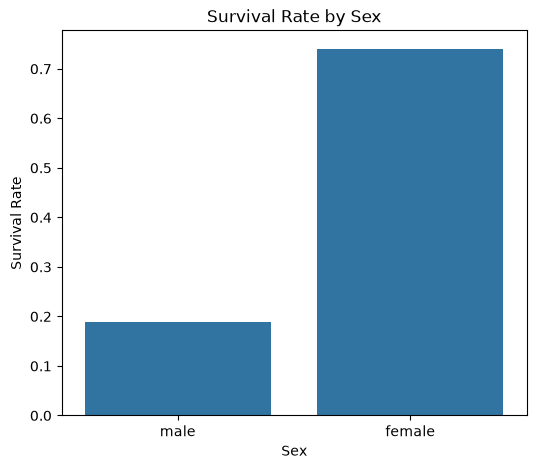

In [22]:
plt.figure(figsize=(6, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived",
    estimator="mean",
    errorbar=None
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()


### Interpretation:

The bar chart shows a substantial difference in survival rates between `male` and `female` passengers. Female passengers had a significantly higher probability of surviving than male passengers, indicating that sex was one of the strongest factors influencing survival. This supports the historical observation that women were given priority during the evacuation.


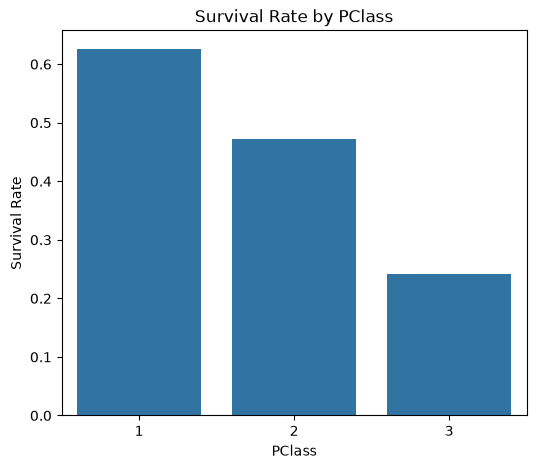

In [23]:
plt.figure(figsize=(6, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    estimator="mean",
    errorbar=None
)

plt.title("Survival Rate by PClass")
plt.xlabel("PClass")
plt.ylabel("Survival Rate")

plt.show()


### Interpretation:

Survival rates varied considerably across passenger classes, with first-class passengers having the highest survival rate and third-class passengers the lowest. This suggests that socioeconomic status or cabin location may have influenced access to lifeboats and evacuation procedures. Passenger class was therefore another important factor associated with survival.


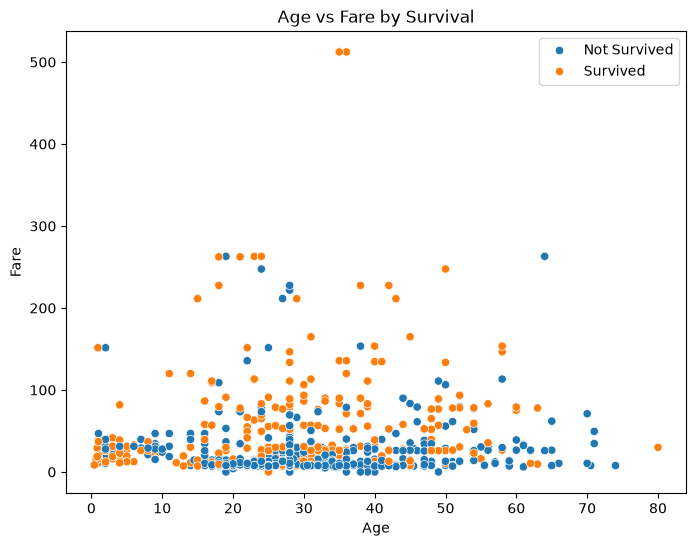

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue=df["survived"].map({0: "Not Survived", 1: "Survived"})
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend()

plt.show()


### Interpretation:

The scatter plot indicates that passengers who paid higher fares were more frequently among the survivors, while those paying lower fares experienced a higher proportion of fatalities. Age alone does not show a clear separation between survivors and non-survivors, suggesting it had a weaker influence than fare. Since higher fares were generally associated with higher passenger classes, this visualization reinforces the relationship between passenger class and survival.


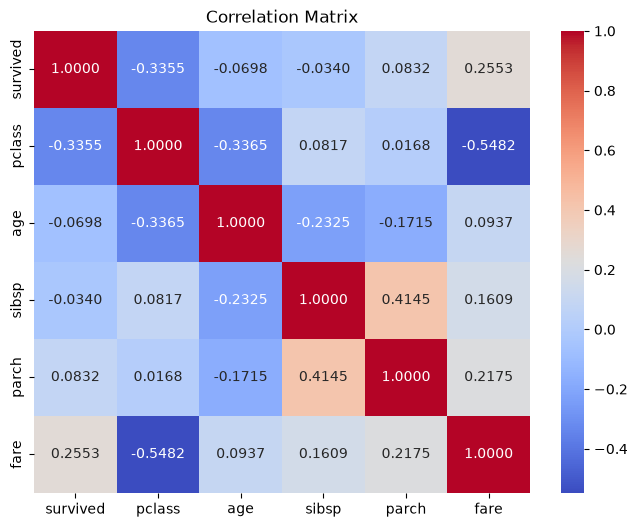

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".4f"
)

plt.title("Correlation Matrix")

plt.show()


### Interpretation:

The correlation heatmap summarizes the relationships among the selected numerical variables. Passenger class and fare exhibit the strongest negative correlation, reflecting that higher-class passengers generally paid higher fares. Survival shows a moderate positive relationship with fare and a negative relationship with passenger class, supporting the earlier findings that wealthier, higher-class passengers were more likely to survive.


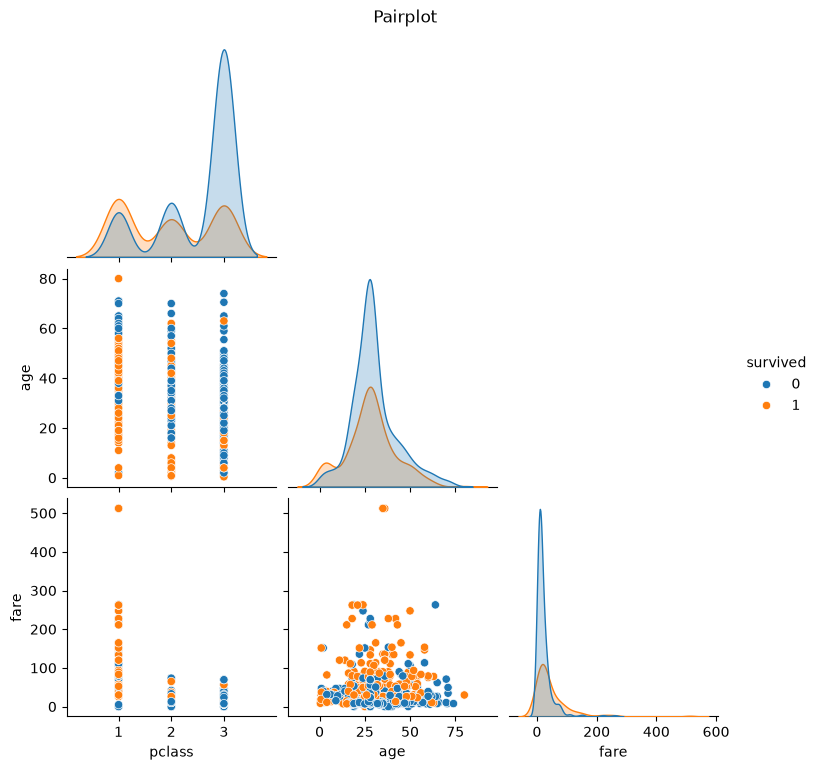

In [26]:
pp_cols= [
    "survived",
    "pclass",
    "age",
    "fare"
]

sns.pairplot(
    df[pp_cols],
    hue="survived",
    corner=True
)

plt.suptitle("Pairplot", y=1.02)

plt.show()


### Interpretation:

The pair plot provides a comprehensive view of the relationships among `survival`, `pclass`, `age`, and `fare`. The visual patterns confirm that survivors are more concentrated among passengers with higher fares and lower passenger class numbers (first class), while age does not show a strong separation between the two groups. Overall, the pair plot reinforces the conclusions drawn from the previous visualizations and presents a cohesive multivariate perspective on the factors influencing survival.


## Exploratory Standardization

As an exploratory validation step, the numerical features **age** and **fare** are standardized using the z-score formula:

`z = (x − mean) / std`

This standardization is performed only as an exploratory data analysis (EDA) sanity check to verify that the transformed features have approximately zero mean and unit standard deviation. It is not used in the predictive modeling pipeline.


In [27]:
df_stz = df.copy()

age_mean = df['age'].mean()
age_std = df['age'].std()

fare_mean = df['fare'].mean()
fare_std = df['fare'].std()

df_stz['age_zscore'] = (df_stz['age'] - age_mean) / age_std
df_stz['fare_zscore'] = (df_stz['fare'] - fare_mean) / fare_std

print("Before Standardization")
print(df[["age", "fare"]].agg(["mean", "std"]))

print("\nAfter Standardization")
print(df_stz[["age_zscore", "fare_zscore"]].agg(["mean", "std"]))


Before Standardization
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After Standardization
        age_zscore   fare_zscore
mean  2.797412e-16  1.358743e-16
std   1.000000e+00  1.000000e+00


In [28]:
df.to_csv('titanic.csv', index=False)
print("Cleaned dataset saved")


Cleaned dataset saved


# Conclusion

This notebook successfully completes the exploratory data analysis (EDA) by:

- Loading the Titanic dataset and creating an offline fallback (`titanic.csv`)
- Profiling the dataset by examining its structure, summary statistics, and missing values
- Cleaning the dataset using a threshold-based missing-value handling strategy
- Performing univariate analysis on **age** and **fare**, including outlier detection using the IQR method
- Analyzing the distribution of **fare** using mean, median, and mode to determine skewness
- Computing survival rates across **sex**, **passenger class**, and their combinations using boolean masking
- Performing correlation analysis on the specified numerical features and interpreting the strongest relationships
- Building a multivariate data story using multiple visualizations with supporting interpretations
- Conducting an exploratory z-score standardization check for **age** and **fare**
- Saving the cleaned dataset as **`titanic.csv`** for use in the predictive modeling pipeline
